In [9]:
import pyodbc 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

conexao = ("Server=DESKTOP-OICCGK1;"
           "Driver=SQL Server;"
           "Database=ContosoRetailDW;"
           "Trusted connection=yes;")

data = pyodbc.connect(conexao)
comando_sql = '''WITH loja_mais_vendeu AS (
SELECT TOP(1)
	StoreName AS 'Nome_Loja',
	SUM(SalesQuantity) AS 'TotalVendido' 
FROM FactSales
LEFT JOIN DimStore
	ON FactSales.StoreKey = DimStore.StoreKey
GROUP BY StoreName
ORDER BY TotalVendido DESC)  
							SELECT 
								StoreName AS 'NomeLoja',
								ProductCategoryName AS 'Categoria',
								SUM(SalesQuantity) AS 'TotalVendas',
								CalendarYear AS 'Ano'
							FROM FactSales
							LEFT JOIN DimProduct
								ON FactSales.ProductKey = DimProduct.ProductKey
							LEFT JOIN DimProductSubcategory AS sub
								ON sub.ProductSubcategoryKey = DimProduct.ProductSubcategoryKey
							LEFT JOIN DimProductCategory AS cat
								ON sub.ProductCategoryKey = cat.ProductCategoryKey
							LEFT JOIN DimStore
								ON FactSales.StoreKey = DimStore.StoreKey
							LEFT JOIN DimDate
								ON FactSales.DateKey = DimDate.Datekey
							WHERE StoreName = (SELECT Nome_Loja FROM loja_mais_vendeu)
							GROUP BY ProductCategoryName,StoreName, CalendarYear'''
tabela = pd.read_sql(comando_sql, data)
vendas_2007 = tabela[tabela["Ano"] == 2007][["Categoria","TotalVendas","Ano"]]
vendas_2008 = tabela[tabela["Ano"] == 2008][["Categoria","TotalVendas","Ano"]]
vendas_2009 = tabela[tabela["Ano"] == 2009][["Categoria","TotalVendas","Ano"]]
display(vendas_2007)
display(vendas_2008)
display(vendas_2009)

C:\Users\usu\AppData\Local\Temp\ipykernel_8784\2698911057.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tabela = pd.read_sql(comando_sql, data)


,Categoria,TotalVendas,Ano
0,Audio,15166,2007
3,Cameras and camcorders,147949,2007
6,Cell phones,222667,2007
9,Computers,207586,2007
12,Games and Toys,270727,2007
15,Home Appliances,200854,2007
18,"Music, Movies and Audio Books",38510,2007
21,TV and Video,70083,2007


,Categoria,TotalVendas,Ano
1,Audio,37068,2008
4,Cameras and camcorders,158351,2008
7,Cell phones,301533,2008
10,Computers,262328,2008
13,Games and Toys,372319,2008
16,Home Appliances,280622,2008
19,"Music, Movies and Audio Books",35532,2008
22,TV and Video,88920,2008


,Categoria,TotalVendas,Ano
2,Audio,55699,2009
5,Cameras and camcorders,179043,2009
8,Cell phones,501186,2009
11,Computers,321270,2009
14,Games and Toys,443584,2009
17,Home Appliances,326726,2009
20,"Music, Movies and Audio Books",37862,2009
23,TV and Video,106057,2009


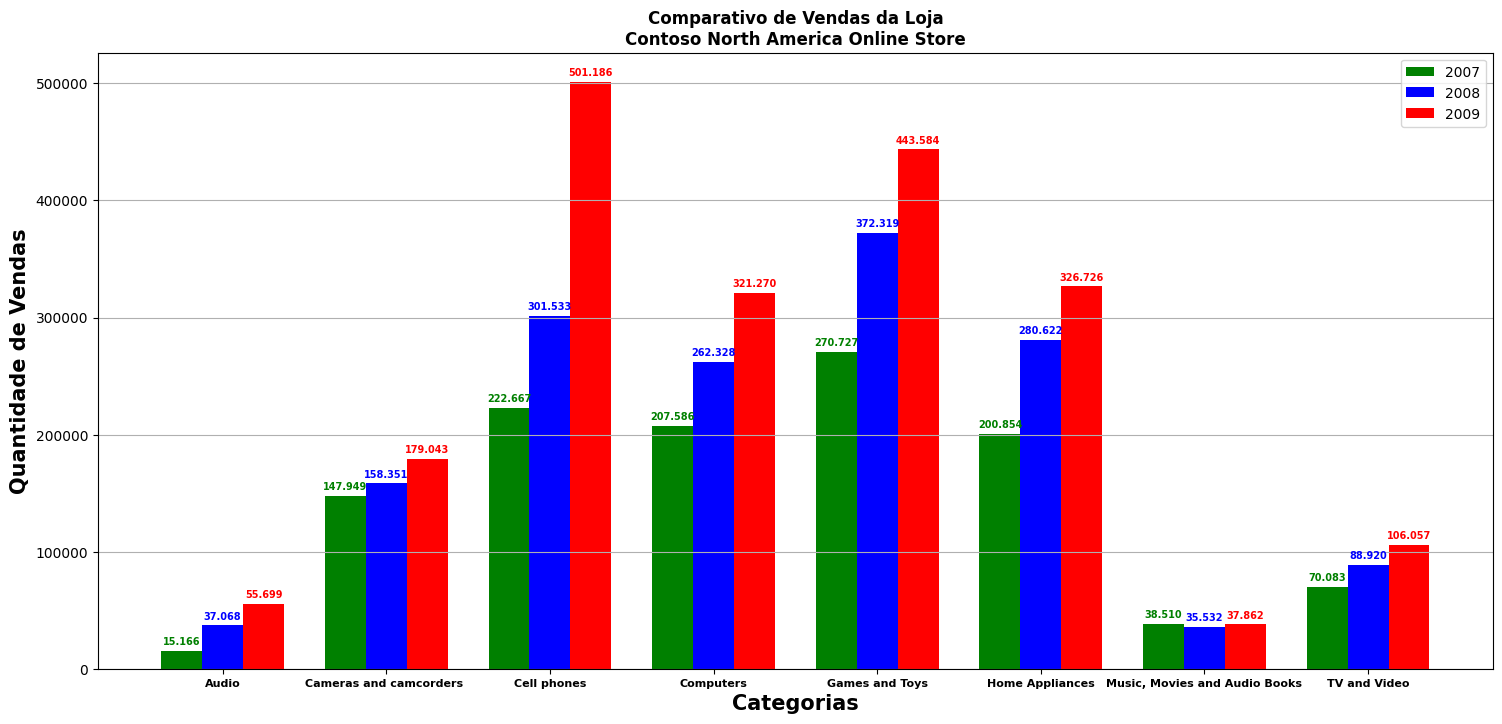

In [14]:
def formatar(valor):
    return "{:,}". format(valor).replace(",",".")

categorias = vendas_2007["Categoria"]
numero_categorias = len(categorias)
x = np. arange(numero_categorias)
largura_barra = 0.25
x2007 = x-largura_barra
x2008 = x
x2009 = x+largura_barra

nome_da_loja = "Contoso North America Online Store"
plt.figure(figsize=(18,8))
plt.title(f"Comparativo de Vendas da Loja\n{nome_da_loja}",fontweight="bold")
plt.ylabel("Quantidade de Vendas",fontsize=15,fontweight="bold")
plt.xlabel("Categorias",fontsize=15,fontweight="bold")
plt.grid(True,axis="y")

barras1 = plt.bar(x2007,vendas_2007["TotalVendas"],width=largura_barra, color="green", label=2007)
barras2 = plt.bar(x2008,vendas_2008["TotalVendas"],width=largura_barra, color="blue", label=2008)
barras3 = plt.bar(x2009,vendas_2009["TotalVendas"],width=largura_barra, color="red", label=2009)

plt.bar_label(barras1,vendas_2007["TotalVendas"].apply(formatar),padding=3,fontweight="bold",color="green",fontsize=7)
plt.bar_label(barras2,vendas_2008["TotalVendas"].apply(formatar),padding=3,fontweight="bold",color="blue",fontsize=7)
plt.bar_label(barras3,vendas_2009["TotalVendas"].apply(formatar),padding=3,fontweight="bold",color="red",fontsize=7)
plt.xticks(x,categorias,fontsize=8,fontweight="bold")

plt.legend()